In [71]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [72]:

def preprocess_design_matrix(design_matrix, col):

    design_matrix['group'] = np.where(
        design_matrix[col] > design_matrix[col].mean(), 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [73]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix     


# Model Training

In [74]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [75]:
design_matrix_otrain = pd.read_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t"
)

In [76]:
rate_col = "CNS Rate"

In [77]:
design_matrix_otrain[rate_col].mean()

0.2619382352941176

In [78]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy(), rate_col)

<Axes: >

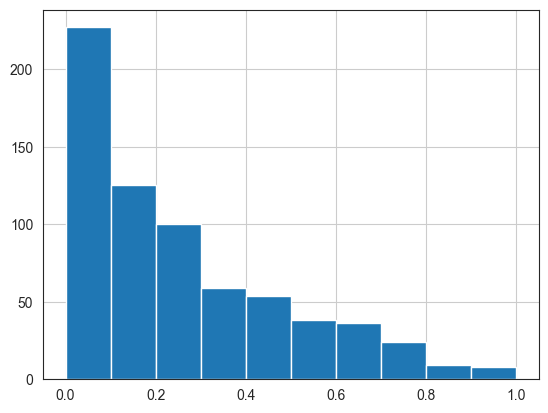

In [79]:
design_matrix_train[rate_col].hist(bins=10)

In [80]:
design_matrix_train['group'].value_counts()

group
1    400
2    280
Name: count, dtype: int64

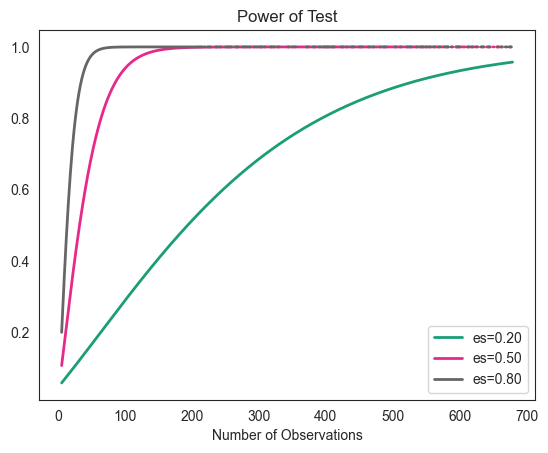

In [81]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [82]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [83]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [84]:
#quant_matrix_train.write("de_results/resp_de_proteins.tsv")

In [85]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

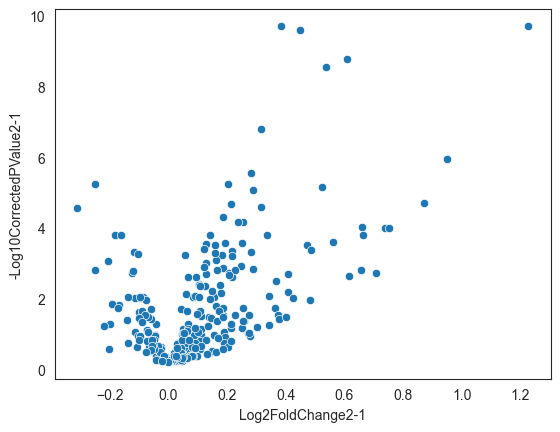

In [86]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [87]:
quant_matrix_de.sort_values("CorrectedPValue2-1")

,Protein,ProteinLabel,DEScore2-1,Group2Mean,Group1Mean,Group2Stdev,Group1Stdev,Log2FoldChange2-1,PValue2-1,Group2RepCounts,...,SA_BOX_7-719_S4-E10_1_5984,SA_BOX_6-746_S2-E6_1_5853,SA_BOX_13-389_S1-B6_1_6537,SA_BOX_6-236_S2-E9_1_5878,SA_BOX_14-2043_S2-A2_1_6602,SA_BOX_11-2056_S4-F8_1_6362,SA_BOX_3-697_S4-A6_1_5555,SA_BOX_8-2367_S5-C12_1_6096,SA_BOX_4-2564_S5-F11_1_5699,SA_BOX_10-131_S2-H6_1_6249
276,Q9Y279,VSIG4_HUMAN,1.397374,7.113391,5.886998,2.221194,2.178311,1.226393,2.155945e-12,280,...,8.632800,3.843913,3.922370,8.381036,3.828391,8.040848,4.412084,8.752571,6.987103,8.367238
230,P01034,CYTC_HUMAN,1.048078,12.381389,11.996551,0.721095,0.649561,0.384838,1.114943e-12,280,...,12.388361,11.367966,11.808035,12.448976,11.842510,12.033297,11.763599,12.130882,11.829693,11.762052
123,P61769,B2MG_HUMAN,1.018810,12.229235,11.781015,0.879257,0.765472,0.448220,4.294803e-12,280,...,12.652368,10.490738,11.618301,12.289228,11.372313,11.781104,10.906047,11.750655,11.657643,12.220980
107,P18065,IBP2_HUMAN,1.003807,10.510179,9.901040,1.016198,1.252185,0.609138,3.745344e-11,280,...,11.233598,4.060034,10.352136,11.525362,9.643937,10.984311,9.458948,10.260785,11.075334,10.068544
154,P01033,TIMP1_HUMAN,0.952296,10.647080,10.108582,1.151518,0.962478,0.538497,7.936427e-11,280,...,11.305144,9.690175,10.005689,11.112195,9.291888,10.080163,9.175368,10.305271,10.987082,9.923244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211,P36980,FHR2_HUMAN,0.001983,12.677739,12.679834,0.705313,0.832245,-0.002095,9.726435e-01,280,...,13.264757,11.685098,12.475846,13.238187,11.899713,11.908485,12.578427,13.067585,12.490547,13.494551
105,P33151,CADH5_HUMAN,0.001358,11.292569,11.293704,0.443985,0.419210,-0.001134,9.730164e-01,280,...,12.017946,11.200004,11.240495,11.946617,11.174273,10.991670,11.235114,11.220080,11.062299,11.396095
40,Q04756,HGFA_HUMAN,0.000661,11.908785,11.909413,0.580956,0.545382,-0.000628,9.885493e-01,280,...,12.781411,12.623788,12.066186,13.079095,11.749064,12.426054,12.091453,12.086964,12.809879,11.833706
277,Q9NPH3,IL1AP_HUMAN,0.000351,10.398048,10.397727,0.510390,0.516153,0.000321,9.936079e-01,280,...,10.359477,10.830893,11.205888,10.997268,9.489129,10.582078,10.919976,10.010054,9.905704,10.688069


In [88]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [89]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [90]:
protein_columns = training_data.columns.to_list()

In [91]:
len(protein_columns)

287

In [92]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf
# )

In [94]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy", "roc_auc"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean(), eval_result['test_roc_auc'].mean()

(0.5714939373141158,
 0.5845900419788511,
 0.6558873598170313,
 0.6431984331391586,
 0.7159693950385582)

In [ ]:
from dpks.interpretation import FeatureImportance
import warnings
warnings.filterwarnings("ignore")

feature_importance_results = []

for i, (train, test) in enumerate(cv.split(X, y)):

    train_data = X.iloc[train][protein_columns]
    test_data = X.iloc[test][protein_columns]

    y_train = y.iloc[train]
    y_test = y.iloc[test]

    feature_importance = FeatureImportance(
        n_iterations=100,
        feature_names=protein_columns,
    )

    protein_clf.fit(train_data[protein_columns], y_train)

    feature_importance.fit(protein_clf, train_data.to_numpy())

    feature_importances = pd.DataFrame(
        {
            "feature": protein_columns,
            f"importance {i}": feature_importance.global_explanations
        }
    ).set_index("feature")

    feature_importance_results.append(feature_importances)

feature_importance_results = pd.concat(feature_importance_results, axis=1)


In [61]:
feature_importance_results['Mean Importance'] = feature_importance_results[feature_importance_results.columns].mean(axis=1)

In [62]:
feature_importance_results.sort_values("Mean Importance", ascending=False, inplace=True)
feature_importance_results


,importance 0,importance 1,importance 2,Mean Importance
feature,,,,
ACTN4_HUMAN,0.920723,0.684218,0.975134,0.860025
SAMP_HUMAN,0.497237,0.619075,1.099927,0.738746
FBLN5_HUMAN,0.701330,0.573289,0.756513,0.677044
CO8G_HUMAN,0.796859,0.380871,0.646971,0.608234
CADH5_HUMAN,0.606166,0.483514,0.703893,0.597858
...,...,...,...,...
CALR_HUMAN,0.013872,0.023300,0.061486,0.032886
GELS_HUMAN,0.005522,0.034154,0.054652,0.031443
PROP_HUMAN,0.073436,0.006220,0.001799,0.027152


In [63]:
feature_importance_results = feature_importance_results.reset_index()
feature_importance_results['feature'] = feature_importance_results['feature'].str.replace("_HUMAN", "")

In [64]:
import colorcet as cc

In [65]:
colormap = cc.glasbey_cool

In [66]:
color = colormap[1]

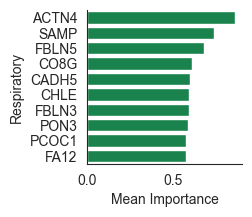

In [67]:
sns.set_style("white")

fig, ax = plt.subplots()

sns.barplot(
    data=feature_importance_results.reset_index().head(10),
    x="Mean Importance",
    y="feature",
    ax=ax,
    color=color,
)

ax.set_ylabel("Respiratory")
sns.despine()
fig.set_size_inches(
    (2, 2)
)

In [68]:
feature_importance_results["Panel"] = "CNS"

In [69]:
feature_importance_results.to_csv(
    "cns_importance.tsv",
    sep="\t",
    index=False
)

In [70]:
from joblib import dump


with open("models/cns_protein_model.pkl", "wb") as f:

    dump(protein_clf, f)

with open("models/cns_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
